# rhinology_reimbursement

- Description: Looking at trends in reimbursement for rhinology procedures based on publicly available medicare data.
- Author: Ravi Bandaru
- Date: February 8, 2026
- Contact: ravi.bandaru@students.jefferson.edu



### Start off by cleaning all of the data.

In [53]:
import pandas as pd

physician_fee_schedules = {}

base_path = "/projects/b1198/epifluidlab/ravi/rhinology_reimbursment/raw_data/reimbursement_cpt_codes"

columns_to_keep = ["HCPCS Code", "Facility Price", "Work RVU"]

for year in range(2000, 2026):
    file_path = f"{base_path}/{year}.csv"
    df = pd.read_csv(file_path)
    df = df.loc[:, df.columns.intersection(columns_to_keep)].copy()
    df["Year"] = year
    physician_fee_schedules[year] = df

combined_df = pd.concat(physician_fee_schedules.values(), ignore_index=True)

combined_df = combined_df[["Year", "HCPCS Code", "Facility Price", "Work RVU"]]

inflation_path = "/projects/b1198/epifluidlab/ravi/rhinology_reimbursment/raw_data/inflation_table.csv"
inflation_df = pd.read_csv(inflation_path)

combined_df = combined_df.merge(inflation_df, on="Year", how="left")

combined_df["Facility Price"] = pd.to_numeric(combined_df["Facility Price"], errors="coerce")

combined_df["Facility Price (Inflation Adjusted)"] = (
    combined_df["Facility Price"] * combined_df["Inflation Factor"]
)

In [54]:
grouping_path = "/projects/b1198/epifluidlab/ravi/rhinology_reimbursment/raw_data/grouping_cpt_codes.csv"
grouping_df = pd.read_csv(grouping_path)

combined_df["HCPCS Code"] = combined_df["HCPCS Code"].astype(str)
grouping_df["CPT Code"] = grouping_df["CPT Code"].astype(str)

combined_df = combined_df.merge(
    grouping_df[["CPT Code", "Group Name", "Group Number"]],
    left_on="HCPCS Code",
    right_on="CPT Code",
    how="left"
)

combined_df = combined_df.drop(columns=["CPT Code"])

grouped_df = (
    combined_df
    .groupby(["Year", "Group Name"], as_index=False)
    .mean(numeric_only=True)
)

work_rvu = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Work RVU"
).sort_index(axis=1)

facility_price = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Facility Price"
).sort_index(axis=1)

inflation_facility_price = grouped_df.pivot(
    index="Group Name",
    columns="Year",
    values="Facility Price (Inflation Adjusted)"
).sort_index(axis=1)

### Create the Nominal Facility Price Chart, Inflation Facility Price Chart, and Work RVUs Chart

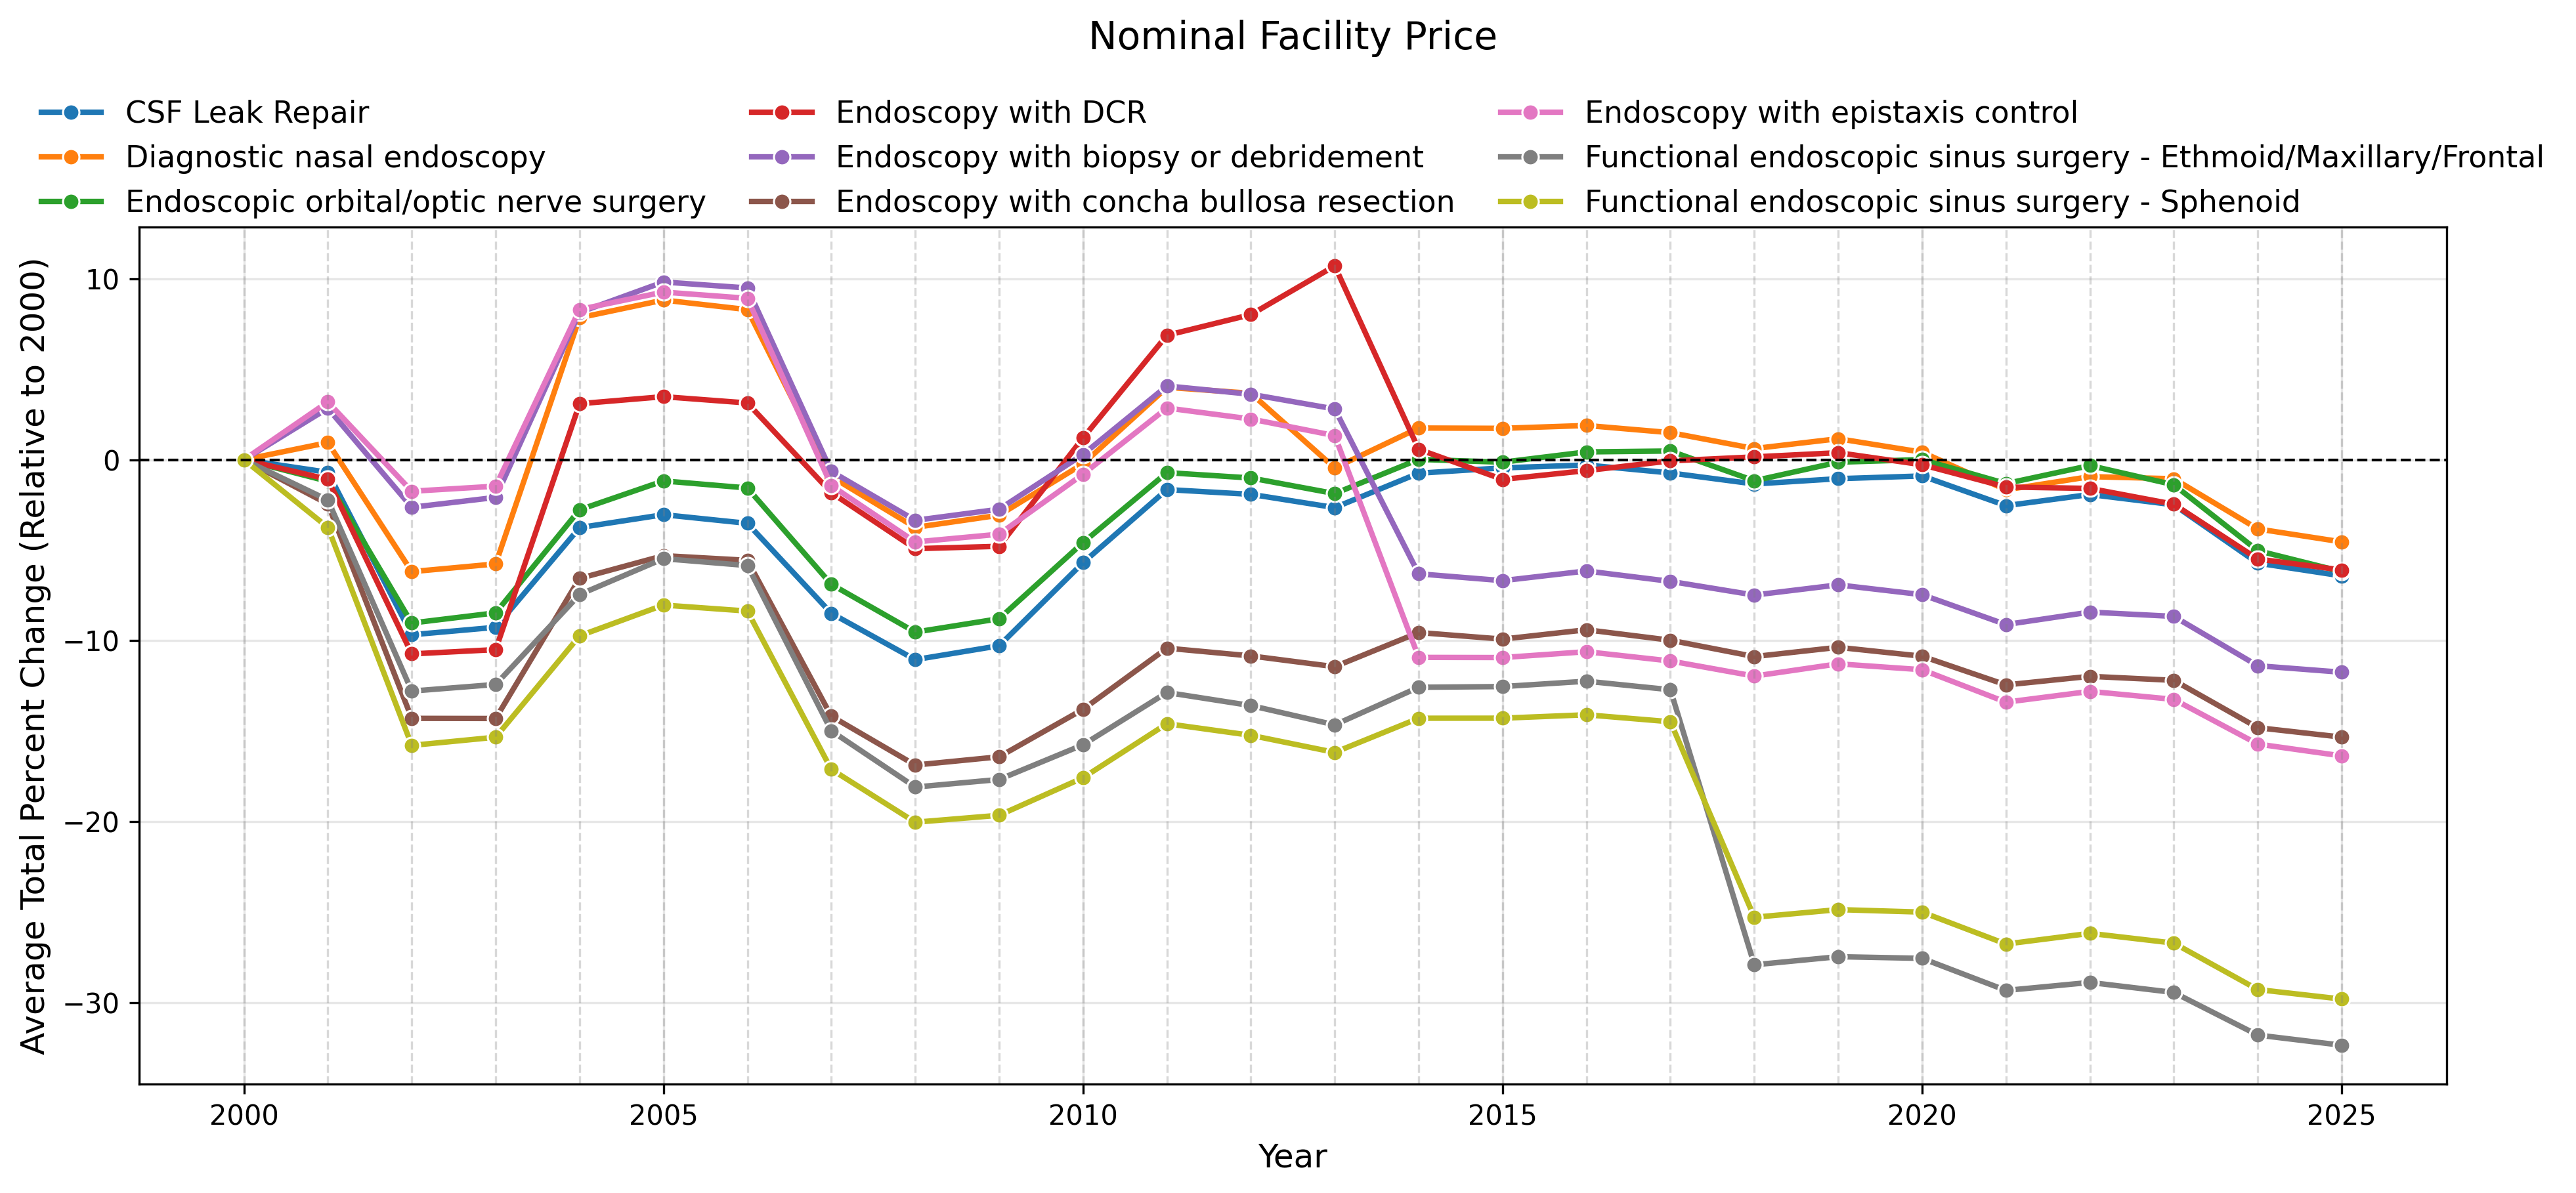

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

baseline_year = 2000

facility_pct_change = (
    facility_price
    .subtract(facility_price[baseline_year], axis=0)
    .divide(facility_price[baseline_year], axis=0)
    * 100
)

plot_df = (
    facility_pct_change
    .reset_index()
    .melt(
        id_vars="Group Name",
        var_name="Year",
        value_name="Percent Change"
    )
)

plot_df["Year"] = plot_df["Year"].astype(int)

plt.figure(figsize=(14, 7), dpi=300)

ax = sns.lineplot(
    data=plot_df,
    x="Year",
    y="Percent Change",
    hue="Group Name",
    marker="o",
    style="Group Name",
    dashes=False,
    markersize=6,
    linewidth=2
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.title("Nominal Facility Price", fontsize=14, pad=65)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Total Percent Change (Relative to 2000)", fontsize=12)

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,                
    frameon=False,
    fontsize=11,
    handlelength=2.0,
    columnspacing=1.5
)

plt.grid(alpha=0.3)
for year in plot_df["Year"].unique():
    plt.axvline(x=year, linestyle="--", color="gray", alpha=0.3, linewidth=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.88])

plt.show()


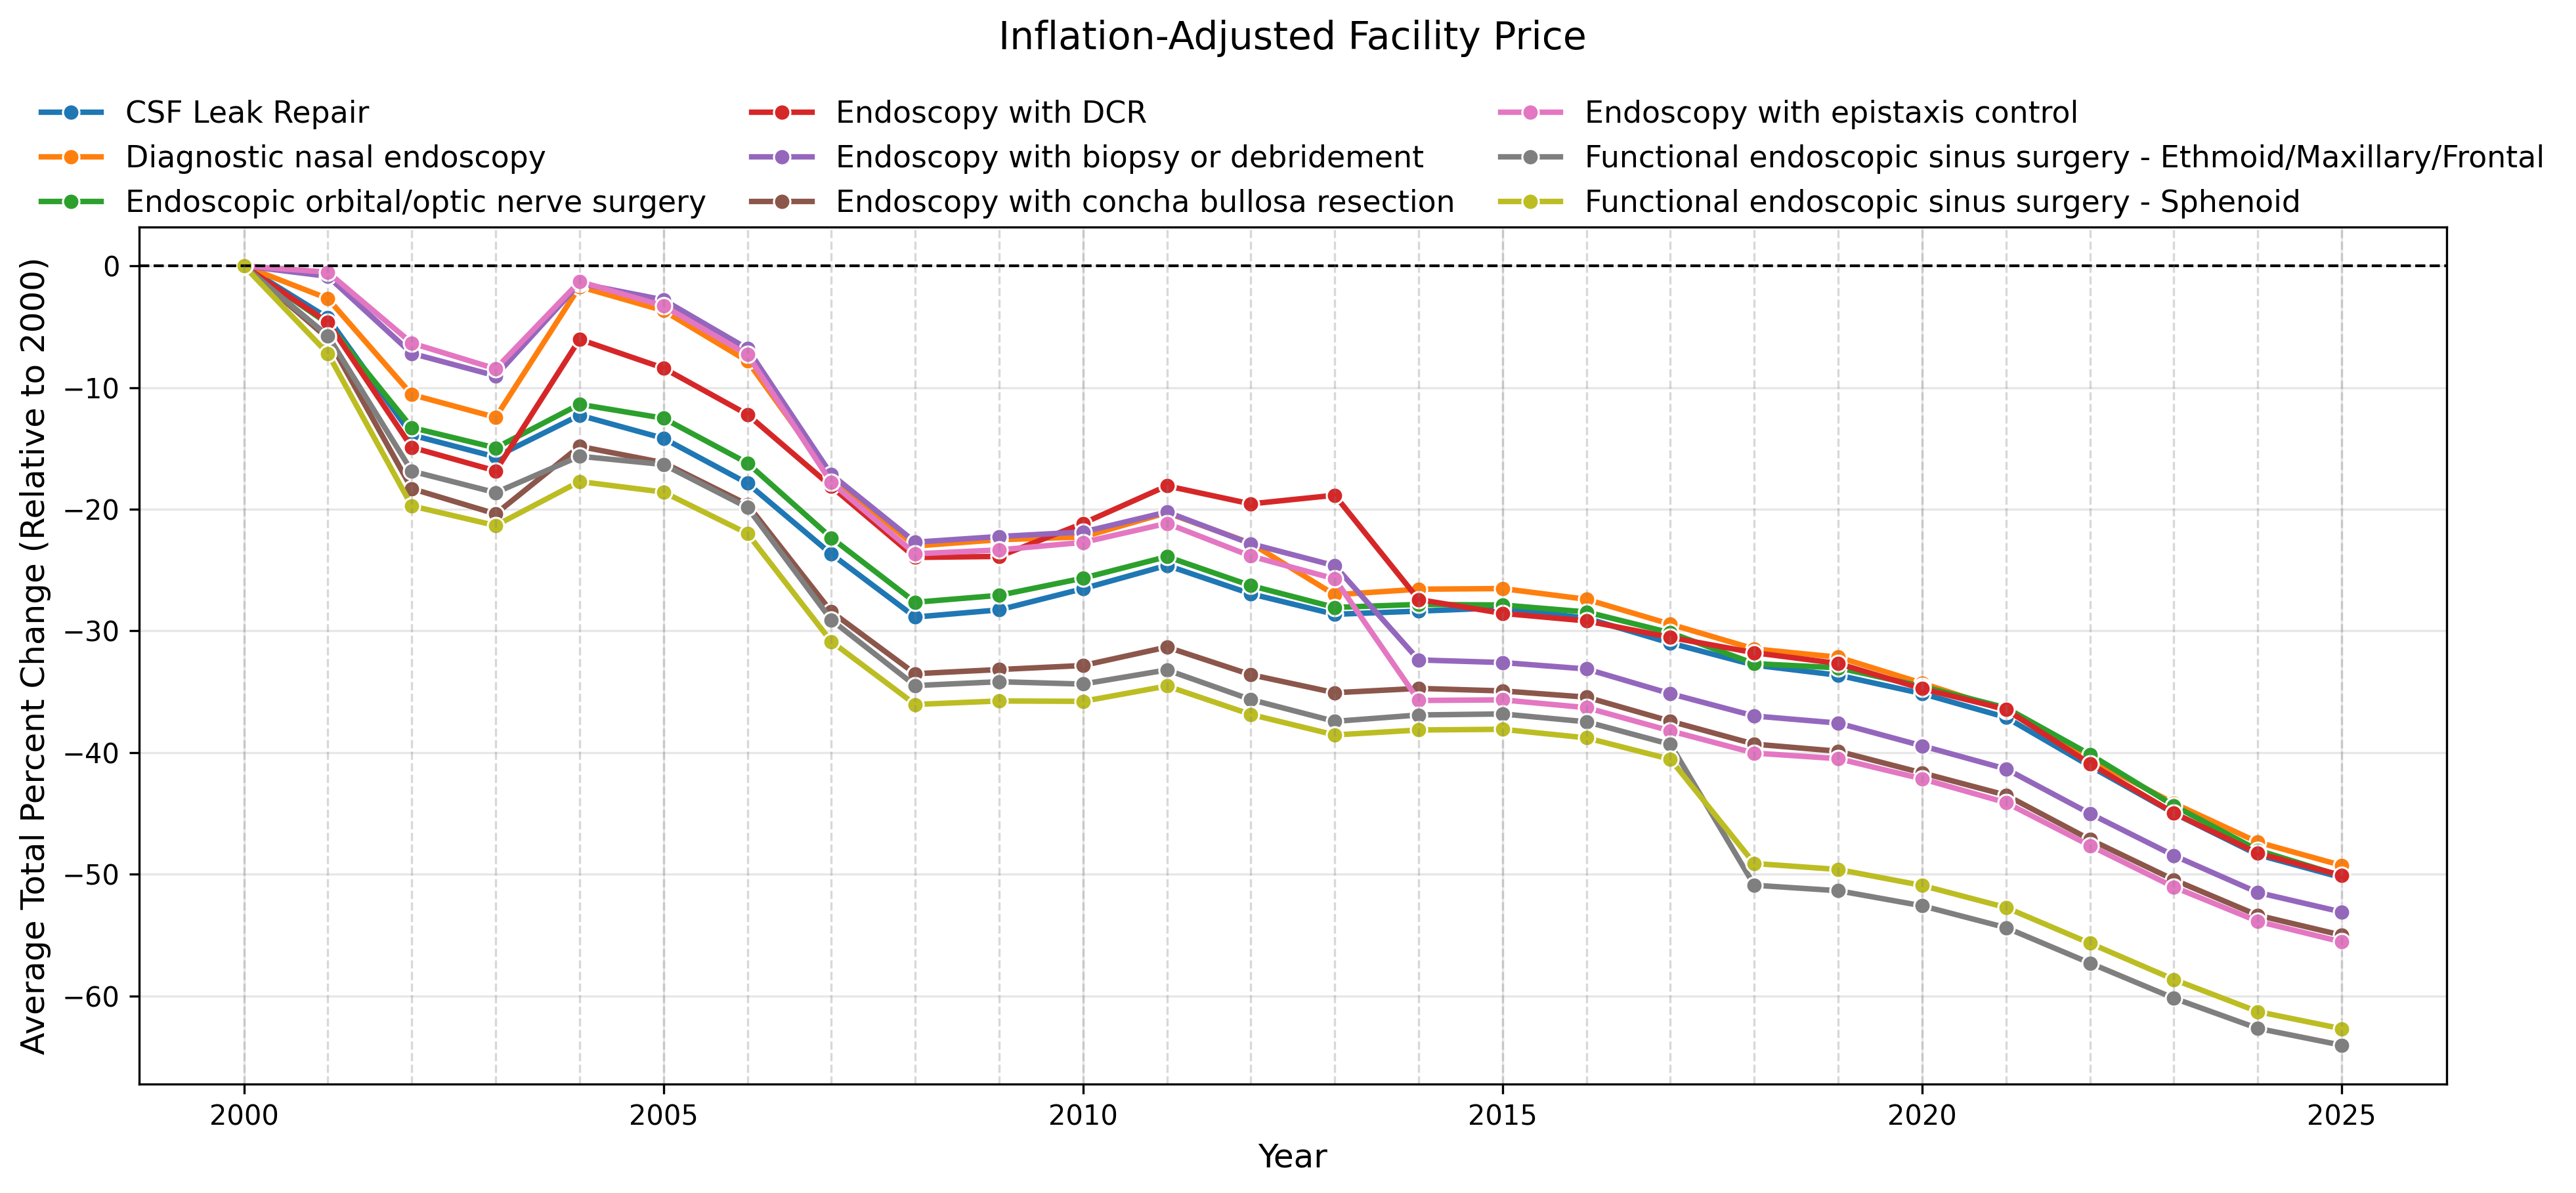

In [72]:
inflation_facility_pct_change = (
    inflation_facility_price
    .subtract(inflation_facility_price[baseline_year], axis=0)
    .divide(inflation_facility_price[baseline_year], axis=0)
    * 100
)

plot_df = (
    inflation_facility_pct_change
    .reset_index()
    .melt(
        id_vars="Group Name",
        var_name="Year",
        value_name="Percent Change"
    )
)

plot_df["Year"] = plot_df["Year"].astype(int)

plt.figure(figsize=(14, 7), dpi=300)

ax = sns.lineplot(
    data=plot_df,
    x="Year",
    y="Percent Change",
    hue="Group Name",
    marker="o",
    style="Group Name",
    dashes=False,
    markersize=6,
    linewidth=2
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.title("Inflation-Adjusted Facility Price", fontsize=14, pad=65)
plt.xlabel("Year", fontsize=12)
plt.ylabel(f"Average Total Percent Change (Relative to {baseline_year})", fontsize=12)

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,
    frameon=False,
    fontsize=11,
    handlelength=2.0,
    columnspacing=1.5
)

plt.grid(alpha=0.3)

for year in plot_df["Year"].unique():
    plt.axvline(x=year, linestyle="--", color="gray", alpha=0.3, linewidth=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


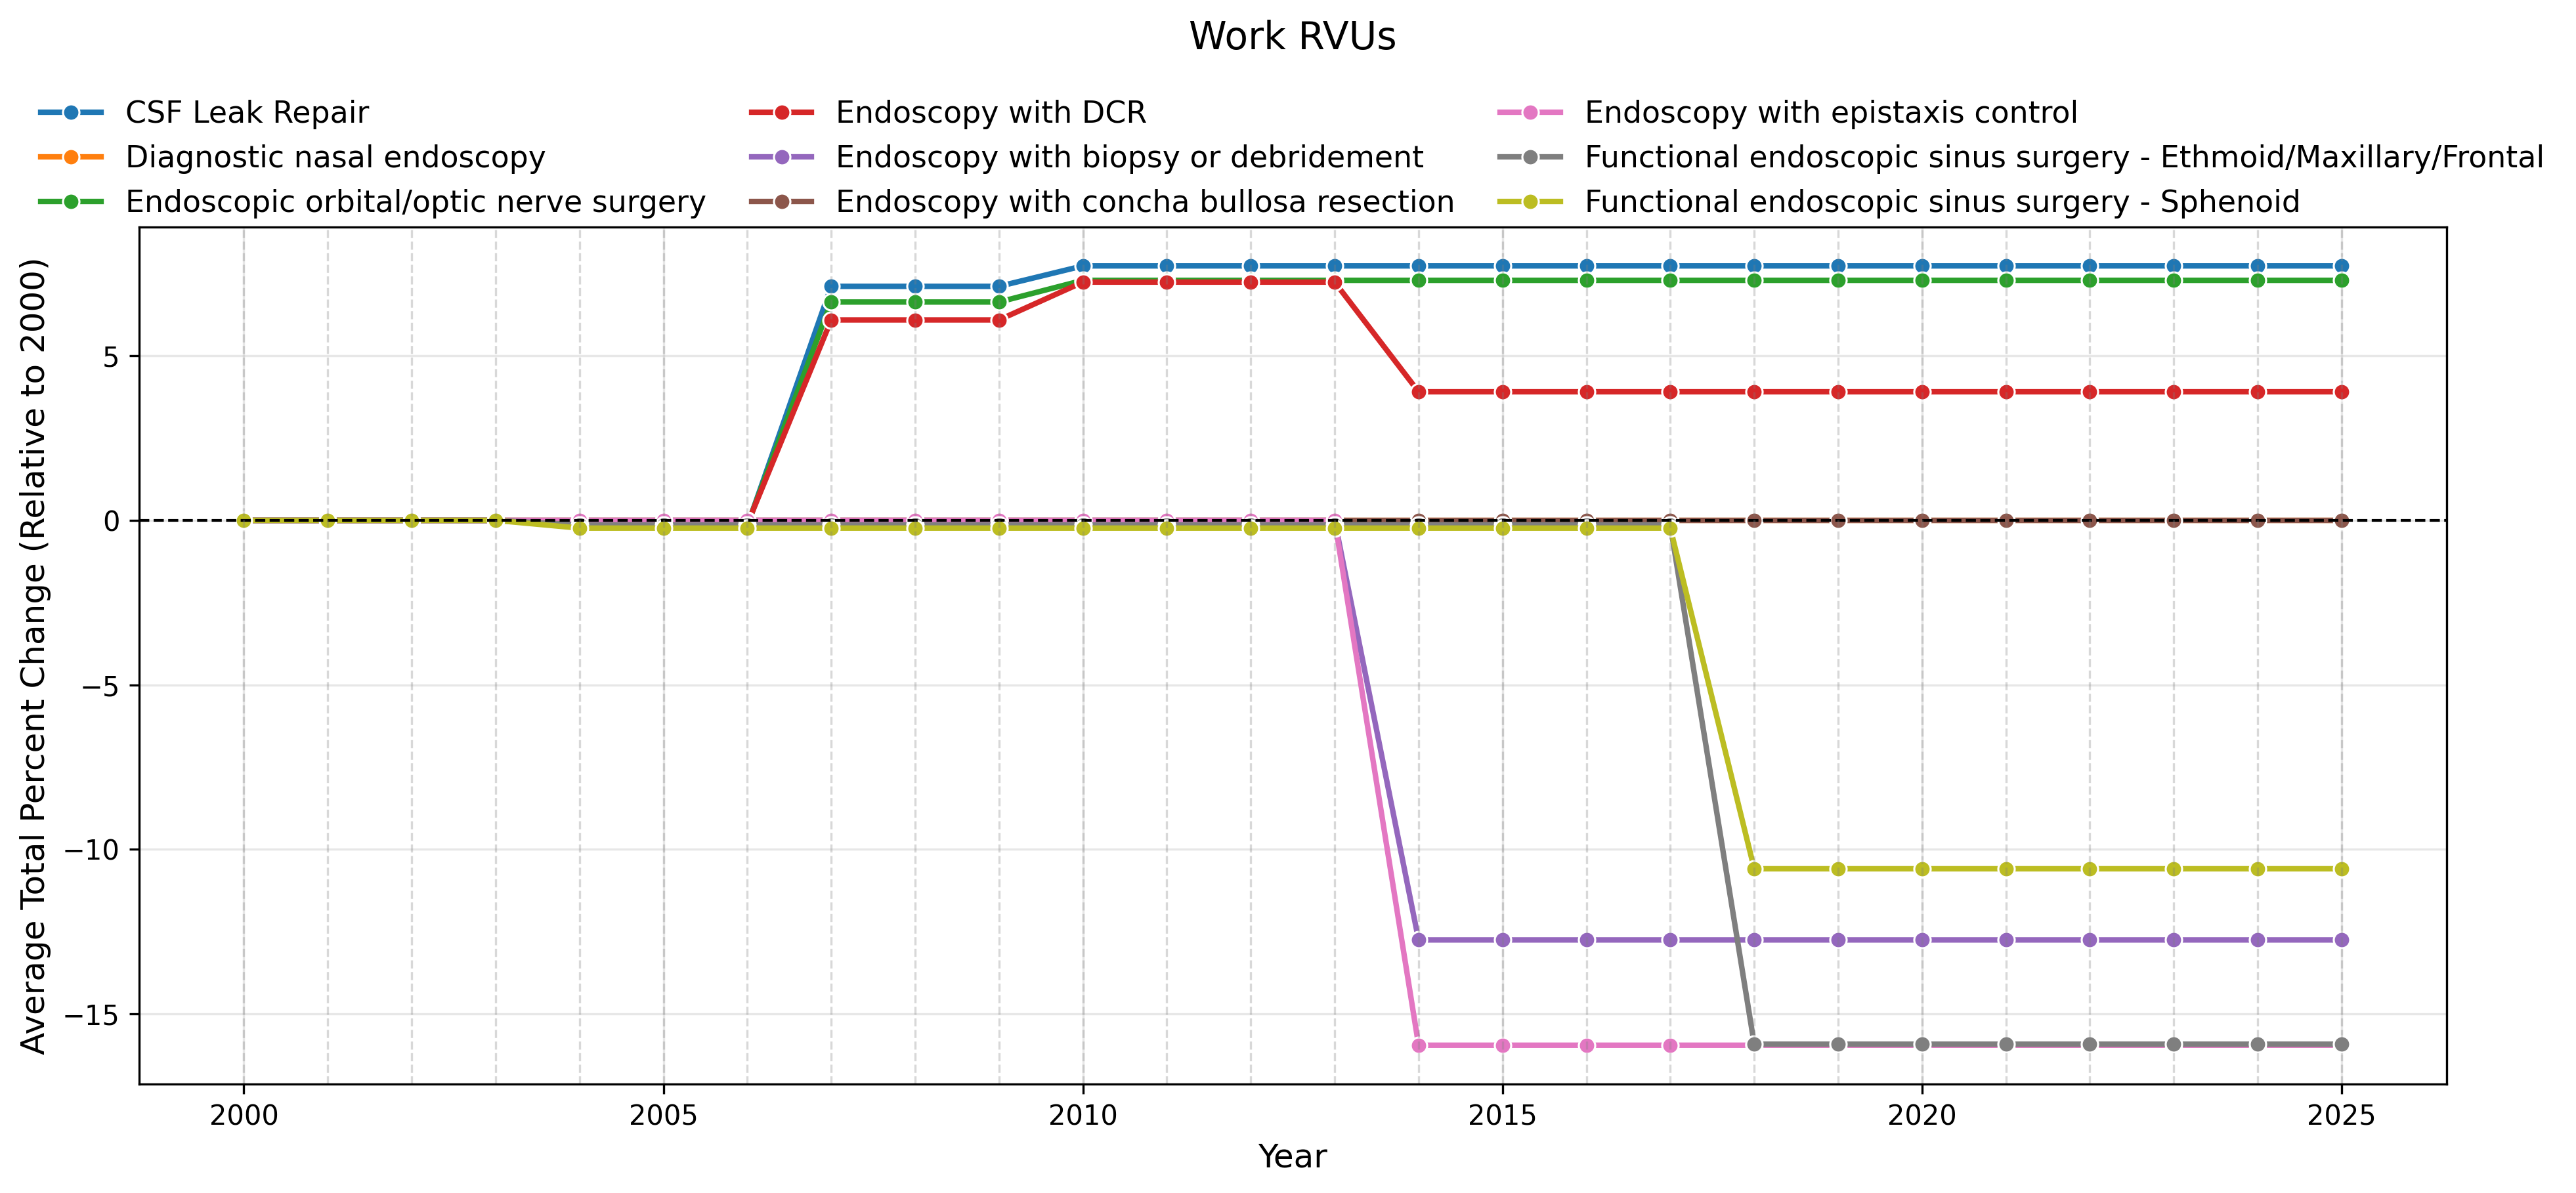

In [74]:
work_rvu_pct_change = (
    work_rvu
    .subtract(work_rvu[baseline_year], axis=0)
    .divide(work_rvu[baseline_year], axis=0)
    * 100
)

plot_df = (
    work_rvu_pct_change
    .reset_index()
    .melt(
        id_vars="Group Name",
        var_name="Year",
        value_name="Percent Change"
    )
)

plot_df["Year"] = plot_df["Year"].astype(int)

plt.figure(figsize=(14, 7), dpi=300)

ax = sns.lineplot(
    data=plot_df,
    x="Year",
    y="Percent Change",
    hue="Group Name",
    marker="o",
    style="Group Name",
    dashes=False,
    markersize=6,
    linewidth=2
)

plt.axhline(0, linestyle="--", color="black", linewidth=1)

plt.title("Work RVUs", fontsize=14, pad=65)
plt.xlabel("Year", fontsize=12)
plt.ylabel(f"Average Total Percent Change (Relative to {baseline_year})", fontsize=12)

ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=3,
    frameon=False,
    fontsize=11,
    handlelength=2.0,
    columnspacing=1.5
)

plt.grid(alpha=0.3)

for year in plot_df["Year"].unique():
    plt.axvline(x=year, linestyle="--", color="gray", alpha=0.3, linewidth=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()


### Now need to figure out how to clean the utilization data and plot it.